In [1]:
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
from datetime import datetime
from datetime import timedelta
from pandas.plotting import register_matplotlib_converters
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
register_matplotlib_converters()
from time import time
from pmdarima import auto_arima
from statsmodels.tsa.arima_model import ARIMA
import statsmodels.api as sm

In [2]:
def parser(s):
    return datetime.strptime(s, '%d-%m-%y')

In [3]:
df = pd.read_csv(r"C:\Users\USER\Downloads\PZData.csv", parse_dates=[0], index_col=0, date_parser=parser)

C:\Users\USER\AppData\Local\Temp\ipykernel_5740\1082114984.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df = pd.read_csv(r"C:\Users\USER\Downloads\PZData.csv", parse_dates=[0], index_col=0, date_parser=parser)


In [4]:
#infer the frequency of the data
df = df.asfreq(pd.infer_freq(df.index))

In [5]:
start_date = datetime(2015,1,1)
end_date = datetime(2023,11,22)
lim_df = df[start_date:end_date]
df=df.dropna()
df.head() 

,Price
Date,
2015-01-05,23.99
2015-01-06,25.18
2015-01-07,26.50
2015-01-08,25.30
2015-01-09,24.54


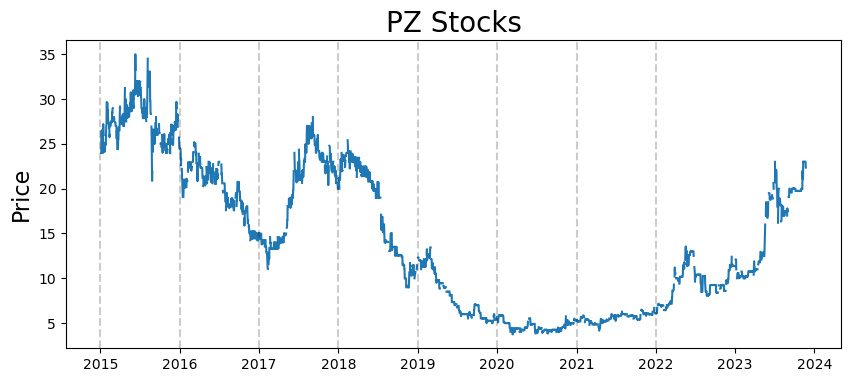

In [6]:
plt.figure(figsize=(10,4))
plt.plot(lim_df)
lim_df=lim_df.dropna()
plt.title('PZ Stocks', fontsize=20)
plt.ylabel('Price', fontsize=16)
for year in range(start_date.year,end_date.year):
    plt.axvline(pd.to_datetime(str(year)+'-01-01'), color='k', linestyle='--', alpha=0.2)

In [7]:
from statsmodels.tsa.stattools import adfuller

def adf_test(dataset):
  dftest = adfuller(dataset, autolag = 'AIC')
  print("1. ADF : ",dftest[0])
  print("2. P-Value : ", dftest[1])
  print("3. Num Of Lags : ", dftest[2])
  print("4. Num Of Observations Used For ADF Regression and Critical Values Calculation :", dftest[3])
  print("5. Critical Values :")
  for key, val in dftest[4].items():
      print("\t",key, ": ", val)


In [8]:
adf_test(df['Price'])

1. ADF :  -1.3799467278651478
2. P-Value :  0.5918512622553317
3. Num Of Lags :  5
4. Num Of Observations Used For ADF Regression and Critical Values Calculation : 2195
5. Critical Values :
	 1% :  -3.4333326714656223
	 5% :  -2.8628576479452597
	 10% :  -2.5674714486226202


In [9]:
from statsmodels.tsa.arima_model import ARIMA

In [33]:
print(df.shape)
train=df.iloc[:-100]
test=df.iloc[-100:]
print(train.shape,test.shape)
print(test.iloc[0],test.iloc[-1])
train.tail()

(2201, 1)
(2101, 1) (100, 1)
Price    20.7
Name: 2023-07-04 00:00:00, dtype: float64 Price    22.35
Name: 2023-11-22 00:00:00, dtype: float64


,Price
Date,
2023-06-23,18.90
2023-06-26,20.65
2023-06-27,20.00
2023-06-30,22.00
2023-07-03,23.00


In [34]:
from pmdarima import auto_arima
# Ignore harmless warnings
import warnings
warnings.filterwarnings("ignore")

In [23]:
stepwise_fit = auto_arima(train, start_p=0, d=3, start_q=0,
                            trace=True,
                          suppress_warnings=True)           

stepwise_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(0,3,0)(0,0,0)[0]             : AIC=7608.782, Time=0.13 sec
 ARIMA(1,3,0)(0,0,0)[0]             : AIC=6337.400, Time=0.18 sec
 ARIMA(0,3,1)(0,0,0)[0]             : AIC=inf, Time=0.77 sec
 ARIMA(2,3,0)(0,0,0)[0]             : AIC=5800.925, Time=0.22 sec
 ARIMA(3,3,0)(0,0,0)[0]             : AIC=5366.213, Time=0.33 sec
 ARIMA(4,3,0)(0,0,0)[0]             : AIC=5128.015, Time=0.44 sec
 ARIMA(5,3,0)(0,0,0)[0]             : AIC=4908.150, Time=0.60 sec
 ARIMA(5,3,1)(0,0,0)[0]             : AIC=inf, Time=6.32 sec
 ARIMA(4,3,1)(0,0,0)[0]             : AIC=inf, Time=3.38 sec
 ARIMA(5,3,0)(0,0,0)[0] intercept   : AIC=4910.149, Time=1.12 sec

Best model:  ARIMA(5,3,0)(0,0,0)[0]          
Total fit time: 13.508 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2144
Model:               SARIMAX(5, 3, 0)   Log Likelihood               -2448.075
Date:                Wed, 10 Jan 2024   AIC                           4908.150
Time:                        17:42:08   BIC                           4942.164
Sample:                             0   HQIC                          4920.596
                               - 2144                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.4320      0.013   -107.723      0.000      -1.458      -1.406
ar.L2         -1.4493      0.021    -68.070      0.000      -1.491      -1.408
ar.L3         -1.1967      0.025    -48.213      0.000      -1.245      -1.148
ar.L4         -0.7480      0.022    -34.479      0.000      -0.791      -0.706
ar.L5         -0.3158      0.014    -22.105      0.000      -0.344      -0.288
sigma2         0.5756      0.010     56.184      0.000       0.556       0.596
===================================================================================
Ljung-Box (L1) (Q):                  13.43   Jarque-Bera (JB):              1736.19
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.22   Skew:                            -0.23
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.39
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [35]:
from statsmodels.tsa.arima.model import ARIMA
model=ARIMA(train['Price'],order=(5,3,0))
model=model.fit()
#model.summary()

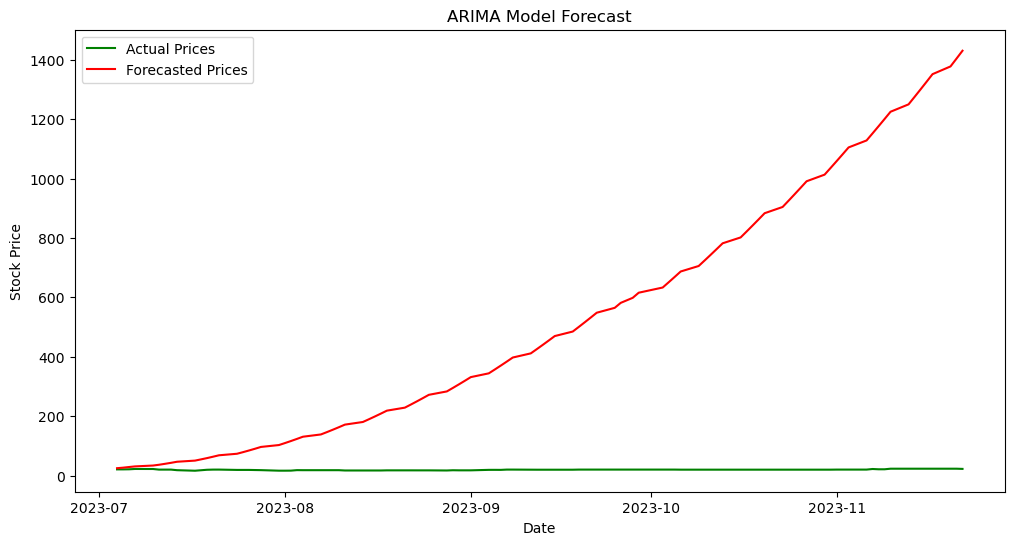

In [36]:
start=len(train)
end=len(train)+len(test)-1
pred=model.predict(start=start,end=end,typ='levels').rename('ARIMA predictions')
pred.index=df.index[start:end+1]
#print(pred)

#if the predicted values dont have date values as index, you will have to uncomment the following two commented lines to plot a graph
#index_future_dates=pd.date_range(start='2022-11-22',end='2023-10-12')
#pred=model.predict(start=start,end=end,typ='levels')
#pred.index=index_future_dates
plt.figure(figsize=(12, 6))
plt.plot(test.index, test, label='Actual Prices', color='green')
plt.plot(pred.index, pred, label='Forecasted Prices', color='red')
plt.title('ARIMA Model Forecast')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

In [37]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from math import sqrt
rmse=sqrt(mean_squared_error(pred,test['Price']))
mae=mean_absolute_percentage_error(pred,test['Price'])
print('Root Mean Squared Error:',rmse)
print('Mean Absolute Percentage Error:',mae)

Root Mean Squared Error: 655.8495286693939
Mean Absolute Percentage Error: 0.8766876267382986


In [38]:
import pandoc
jupyter nbconvert Desktop/New folder (2)/ARIMA.ipynb --to latex

SyntaxError: invalid syntax (2050734960.py, line 2)

# model2=ARIMA(df['Price'],order=(1,1,1))
model2=model2.fit()
df.tail()

In [ ]:
index_future_dates=pd.date_range(start='2023-11-16',end='2023-12-16')
pred=model2.predict(start=len(df),end=len(df)+30,typ='levels').rename('ARIMA Predictions')
pred.index=index_future_dates
#print(index_future_dates)
#print(comp_pred)
print(pred)

In [ ]:
pred.plot(figsize=(12,5),legend=True)